<a href="https://colab.research.google.com/github/Allendecodes/Pandas_Part_1/blob/main/Pandas_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pandas

Series - 1D labelled array — like a single column

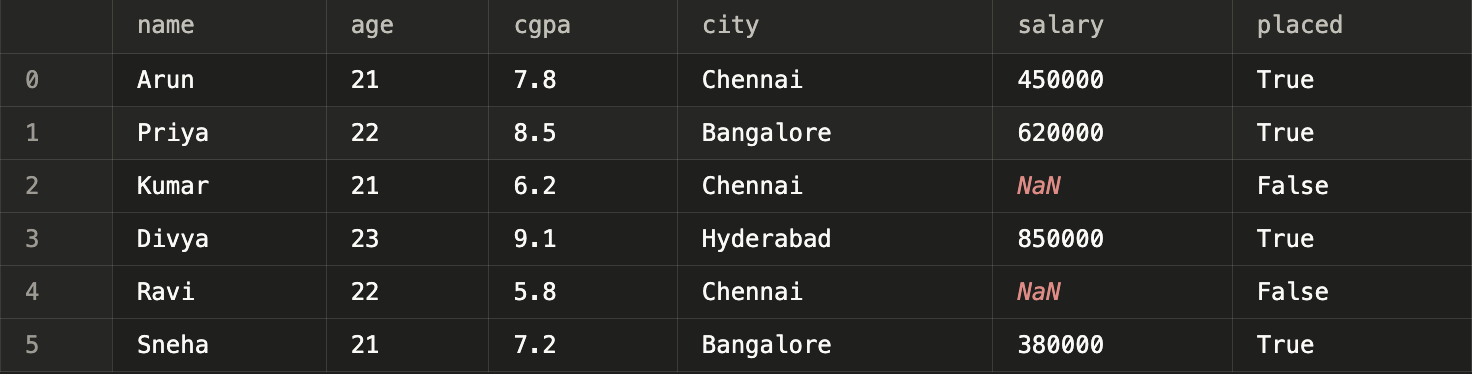

In [ ]:
import numpy as np
import pandas as pd

cgpa = pd.Series([7.8, 8.5, 6.2, 9.1, 5.8, 7.2],
               index = ['Arun','Priya','Kumar','Divya','Ravi','Sneha'],
               name = 'cgpa')

print(cgpa['Arun']) #access by label #loc
print(cgpa[0])      #access by position #iloc
print(cgpa.dtype)
print(cgpa.mean)

7.8
7.8
float64
<bound method Series.mean of Arun     7.8
Priya    8.5
Kumar    6.2
Divya    9.1
Ravi     5.8
Sneha    7.2
Name: cgpa, dtype: float64>


/tmp/ipykernel_2305/2590394746.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(cgpa[0])      #access by position #iloc


Dataframe 2D table with labelled rows AND columns

In [ ]:
df = pd.DataFrame({
    'name'   : ['Arun','Priya','Kumar','Divya','Ravi','Sneha'],
    'age'    : [21, 22, 21, 23, 22, 21],
    'cgpa'   : [7.8, 8.5, 6.2, 9.1, 5.8, 7.2],
    'city'   : ['Chennai','Bangalore','Chennai','Hyderabad','Chennai','Bangalore'],
    'salary' : [450000, 620000, np.nan, 850000, np.nan, 380000],
    'placed' : [True, True, False, True, False, True]
})

#df.shape        (6, 6)  — rows × columns
#df.columns       # Index(['name','age','cgpa','city','salary','placed'])
#df.dtypes        # name:object, age:int64, cgpa:float64...
#df.index         RangeIndex(start=0, stop=6, step=1)

df['cgpa']
df[['name','cgpa']]

,name,cgpa
0,Arun,7.8
1,Priya,8.5
2,Kumar,6.2
3,Divya,9.1
4,Ravi,5.8
5,Sneha,7.2


Single vs double brackets — classic interview trick

df['cgpa'] → returns a Series (1D). df[['cgpa']] → returns a DataFrame (2D, one column). The difference matters when passing data to Scikit-learn — models expect DataFrames, not Series, for features.

First thing to do with any dataset — these 6 lines

In [ ]:
#df.head()          # first 5 rows
#df.tail(3)         # last 3 rows
#df.shape           # (6, 6)
df.info()          # column names, dtypes, non-null counts
#df.describe()      # count, mean, std, min, 25%, 50%, 75%, max
#df.isnull().sum()  # missing values per column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    6 non-null      object 
 1   age     6 non-null      int64  
 2   cgpa    6 non-null      float64
 3   city    6 non-null      object 
 4   salary  4 non-null      float64
 5   placed  6 non-null      bool   
dtypes: bool(1), float64(2), int64(1), object(2)
memory usage: 378.0+ bytes


Adding and dropping columns

Add a column

In [ ]:
df['cgpa_grade'] = df['cgpa'].apply(
    lambda x: 'Distinction' if x >= 8.5 else ('First' if x >= 7.5 else 'Second')
)
df.columns
df.head()

,name,age,cgpa,city,salary,placed,cgpa_grade
0,Arun,21,7.8,Chennai,450000.0,True,First
1,Priya,22,8.5,Bangalore,620000.0,True,Distinction
2,Kumar,21,6.2,Chennai,NaN,False,Second
3,Divya,23,9.1,Hyderabad,850000.0,True,Distinction
4,Ravi,22,5.8,Chennai,NaN,False,Second


Drop a column

In [ ]:
df.drop('cgpa_grade',axis=1,inplace = True)
df.columns
df.head(5)

,name,age,cgpa,city,salary,placed
0,Arun,21,7.8,Chennai,450000.0,True
1,Priya,22,8.5,Bangalore,620000.0,True
2,Kumar,21,6.2,Chennai,NaN,False
3,Divya,23,9.1,Hyderabad,850000.0,True
4,Ravi,22,5.8,Chennai,NaN,False


Drop a row

In [ ]:
df.drop(index=2,axis=0,inplace=True)
df.head()

,name,age,cgpa,city,salary,placed
0,Arun,21,7.8,Chennai,450000.0,True
1,Priya,22,8.5,Bangalore,620000.0,True
3,Divya,23,9.1,Hyderabad,850000.0,True
4,Ravi,22,5.8,Chennai,NaN,False
5,Sneha,21,7.2,Bangalore,380000.0,True


Reset index after dropping rows

In [ ]:
df.reset_index(drop=True, inplace=True)
df.head()

,name,age,cgpa,city,salary,placed
0,Arun,21,7.8,Chennai,450000.0,True
1,Priya,22,8.5,Bangalore,620000.0,True
2,Divya,23,9.1,Hyderabad,850000.0,True
3,Ravi,22,5.8,Chennai,NaN,False
4,Sneha,21,7.2,Bangalore,380000.0,True


Rename columns

In [ ]:
df.rename(columns={'cgpa': 'gpa', 'salary': 'package'}, inplace=True)
df.columns

Index(['name', 'age', 'gpa', 'city', 'package', 'placed'], dtype='object')

**"loc vs iloc"**

The key rule: loc = labels, iloc = integers (positions).



"loc"
 label based (use column NAMES and index LABELS)

# loc[row_label, column_label]

In [ ]:
df.loc[1] #entire row with index label 1

,1
name,Priya
age,22
cgpa,8.5
city,Bangalore
salary,620000.0
placed,True


In [ ]:
df.loc[1, 'cgpa']       # 8.5  — row 1, column 'cgpa'

np.float64(8.5)

In [ ]:
df.loc[1:3, 'name':'cgpa']      # rows 1-3, cols name to cgpa (INCLUSIVE)

,name,age,cgpa
1,Priya,22,8.5
2,Kumar,21,6.2
3,Divya,23,9.1


In [ ]:
df.loc[[0,2,4], ['name','city']] # specific rows and cols


,name,city
0,Arun,Chennai
2,Kumar,Chennai
4,Ravi,Chennai


In [ ]:
df.loc[df['cgpa'] >= 7.5, 'salary']  # salary of high-cgpa students

,salary
0,450000.0
1,620000.0
3,850000.0


In [ ]:
df.loc[df['placed'] == False, 'salary'] = 0  # set unplaced salary to 0

In [ ]:
df

,name,age,cgpa,city,salary,placed
0,Arun,21,7.8,Chennai,450000.0,True
1,Priya,22,8.5,Bangalore,620000.0,True
2,Kumar,21,6.2,Chennai,0.0,False
3,Divya,23,9.1,Hyderabad,850000.0,True
4,Ravi,22,5.8,Chennai,0.0,False
5,Sneha,21,7.2,Bangalore,380000.0,True


iloc

integer position based (use numbers only)

# iloc[row_position, col_position]

In [ ]:
df.iloc[1]           # row at position 1 (second row)

,1
name,Priya
age,22
cgpa,8.5
city,Bangalore
salary,620000.0
placed,True


In [ ]:
df.iloc[1, 2]        # row pos 1, col pos 2 → 8.5 (cgpa)
df.iloc[1:4]         # rows at positions 1,2,3 (stop EXCLUDED)

,name,age,cgpa,city,salary,placed
1,Priya,22,8.5,Bangalore,620000.0,True
2,Kumar,21,6.2,Chennai,0.0,False
3,Divya,23,9.1,Hyderabad,850000.0,True


In [ ]:
df.iloc[:, 0:3]      # all rows, first 3 columns

,name,age,cgpa
0,Arun,21,7.8
1,Priya,22,8.5
2,Kumar,21,6.2
3,Divya,23,9.1
4,Ravi,22,5.8
5,Sneha,21,7.2


In [ ]:
df.iloc[-1]          # last row

,5
name,Sneha
age,21
cgpa,7.2
city,Bangalore
salary,380000.0
placed,True


In [ ]:
df.iloc[-3:, -2:]    # last 3 rows, last 2 columns

,salary,placed
3,850000.0,True
4,0.0,False
5,380000.0,True


In [ ]:
df

,name,age,cgpa,city,salary,placed
0,Arun,21,7.8,Chennai,450000.0,True
1,Priya,22,8.5,Bangalore,620000.0,True
2,Kumar,21,6.2,Chennai,0.0,False
3,Divya,23,9.1,Hyderabad,850000.0,True
4,Ravi,22,5.8,Chennai,0.0,False
5,Sneha,21,7.2,Bangalore,380000.0,True


In [ ]:
df2 = df.drop(index=0)

In [ ]:
df2.loc[1]  # row with label 1 (Priya)   — works

,1
name,Priya
age,22
cgpa,8.5
city,Bangalore
salary,620000.0
placed,True


In [ ]:
df2.iloc[0]   #  row at POSITION 0 (Priya)  — also works

,1
name,Priya
age,22
cgpa,8.5
city,Bangalore
salary,620000.0
placed,True


In [ ]:
df2.loc[0] #it shows key error because notice the indexes are 1,2,3,4,5 after dropping the first row

KeyError: 0

1, 2, 3, 4, 5

.loc[1] uses labels

so it gives priya

df2.loc[0]

gives Keyerror











.iloc[0]

it return priya as its is in the first position
iloc doest care about the index values given in the table it just considers strict counting of rows and columns

like wise

.iloc[1]

it returns Kumar as it is the next position()

This is the trap — after dropping rows, labels ≠ positions Fix: reset_index() to restore 0,1,2... labels

In [ ]:
df2 = df2.reset_index(drop=True)

In [ ]:
df2

,name,age,cgpa,city,salary,placed
1,Priya,22,8.5,Bangalore,620000.0,True
2,Kumar,21,6.2,Chennai,0.0,False
3,Divya,23,9.1,Hyderabad,850000.0,True
4,Ravi,22,5.8,Chennai,0.0,False
5,Sneha,21,7.2,Bangalore,380000.0,True
